# California Wildfires Bluesky Topic Analysis

**Outputs:**
1. Overall BERTopic analysis
2. Week-by-week topic analysis
3. Topic evolution over time

In [31]:
# Import libraries
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer
from bertopic import BERTopic
import umap

# Paths
DATA_DIR = Path("../data/bluesky")
OUTPUT_DIR = Path("../figures/topic_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
POSTS_PATH = DATA_DIR / "posts_all_clean.jsonl"

In [32]:
# --- Load Data and Text Preprocessing ---

# Load posts from JSONL
posts = pd.read_json(POSTS_PATH, lines=True)
print(f"Raw data shape: {posts.shape}")
print(f"created_at column type: {posts['created_at'].dtype}")
print(f"Sample created_at values: {posts['created_at'].head(3).tolist()}")

# Convert created_at to datetime with error handling - handle timezone properly
posts["created_at"] = pd.to_datetime(posts["created_at"], errors='coerce', utc=True)
print(f"After conversion - created_at type: {posts['created_at'].dtype}")

# Check for any conversion errors
if posts['created_at'].isna().any():
    print(f"Warning: {posts['created_at'].isna().sum()} datetime conversion failures")
    posts = posts.dropna(subset=['created_at'])
    print(f"After dropping NaT values - created_at type: {posts['created_at'].dtype}")

# Create date_only column - now should work with proper datetime
print("Creating date_only column...")
posts["date_only"] = posts["created_at"].dt.date
print(f"Successfully created date_only column")
print(f"Sample date_only values: {posts['date_only'].head(3).tolist()}")

print(f"Loaded {len(posts):,} posts")

# Text cleaning patterns
URL_RE = re.compile(r"http[s]?://\S+")
MENTION_RE = re.compile(r"@[A-Za-z0-9_.-]+")
HASHTAG_RE = re.compile(r"#[A-Za-z0-9_]+")
NUMBERS_RE = re.compile(r"\b\d+\b")  # standalone numbers
MONEY_RE = re.compile(r"\$[\d,]+\.?\d*")  # money amounts like $100, $1,000.50

# Custom stop words for wildfire context
CUSTOM_STOPWORDS = set(ENGLISH_STOP_WORDS) | {
    "fire", "fires", "wildfire", "wildfires", "la", "los", "angeles",
    "california", "ca", "palisades", "eaton", "altadena", "pacific",
    "just", "like", "people", "going", "know", "really", "think",
    "time", "new", "want", "way", "good", "right", "need", "make",
    "said", "says", "year", "years", "today", "now", "got", "get",
    "one", "two", "first", "last", "back", "still", "even", "much",
    "many", "well", "also", "come", "take", "see", "day", "days",
    "week", "weeks", "month", "months", "thing", "things", "lot",
    "area", "areas", "home", "homes", "house", "houses", "city",
    "county", "state", "country", "world", "place", "places"
}

def clean_text(text):
    """Clean text for topic modeling."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = URL_RE.sub("", text)
    text = MENTION_RE.sub("", text)
    text = HASHTAG_RE.sub("", text)
    text = MONEY_RE.sub("", text)
    text = NUMBERS_RE.sub("", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    # Remove short words
    words = [w for w in text.split() if len(w) > 2 and w not in CUSTOM_STOPWORDS]
    return " ".join(words)

posts["clean_text"] = posts["text"].apply(clean_text)
posts = posts[posts["clean_text"].str.len() > 20]  # Filter very short posts
print(f"After cleaning: {len(posts):,} posts")

# Verify date_only column exists and has correct data
print(f"Final columns available: {list(posts.columns)}")
print(f"date_only column type: {posts['date_only'].dtype}")
print(f"Sample date_only values: {posts['date_only'].head(3).tolist()}")

Raw data shape: (8834, 13)
created_at column type: object
Sample created_at values: ['2025-01-01T23:45:27.789Z', '2025-01-01T19:03:10.295Z', '2025-01-01T18:34:18.913Z']
After conversion - created_at type: datetime64[ns, UTC]
After dropping NaT values - created_at type: datetime64[ns, UTC]
Creating date_only column...
Successfully created date_only column
Sample date_only values: [datetime.date(2025, 1, 1), datetime.date(2025, 1, 1), datetime.date(2025, 1, 1)]
Loaded 8,115 posts
After cleaning: 7,834 posts
Final columns available: ['uri', 'cid', 'created_at', 'indexed_at', 'author_did', 'author_handle', 'text', 'langs', 'reply_to', 'quoted', 'like_count', 'repost_count', 'clean_text', 'date_only']
date_only column type: object
Sample date_only values: [datetime.date(2025, 1, 1), datetime.date(2025, 1, 1), datetime.date(2025, 1, 1)]


In [33]:
# --- BERTopic Setup ---
# Universal domain stopwords (merged from all sources)
DOMAIN_STOPWORDS = {
    # Fire/location terms (too common, not discriminative)
    "california", "wildfire", "wildfires", "fire", "fires", "los", "angeles",
    "la", "palisades", "eaton", "altadena", "malibu", "pacific",
    
    # Social media noise
    "bluesky", "bsky", "post", "posts", "click", "tap", "trending", "app",
    "twitter", "tweet", "retweet", "thread", "follow", "followers",
    
    # Web artifacts
    "www", "http", "https", "com", "co", "amp", "org", "net",
    
    # Common filler words
    "like", "just", "really", "going", "got", "get", "know", "think",
    "want", "need", "see", "say", "said", "says", "make", "made",
    "way", "thing", "things", "time", "year", "years", "day", "days",
    "people", "new", "good", "right", "lot", "much", "many", "even",
    "still", "back", "now", "today", "tonight", "yesterday", "tomorrow",
    "one", "two", "first", "last", "every", "also",
    
    # Contractions remnants
    "don", "didn", "doesn", "won", "isn", "aren", "wasn", "weren", 
    "let", "ll", "ve", "re", "can", "could", "would", "should",
    
    # Other noise
    "android", "featuring", "press", "youtube", "gaza", "ukrainian",
    "words", "word",
}

ALL_STOPWORDS = list(ENGLISH_STOP_WORDS.union(DOMAIN_STOPWORDS))

def create_topic_model(texts, min_topic_size=10):
    """Create and fit a BERTopic model on texts."""
    if len(texts) < 5:
        return None, None, None
    
    n_neighbors = min(15, len(texts) - 1)
    umap_model = umap.UMAP(
        n_neighbors=n_neighbors,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42
    )
    
    vectorizer_model = CountVectorizer(stop_words=ALL_STOPWORDS)
    
    topic_model = BERTopic(
        vectorizer_model=vectorizer_model,
        low_memory=True,
        umap_model=umap_model,
        min_topic_size=min(min_topic_size, max(5, len(texts) // 10)),
        verbose=False
    )
    
    topics, probs = topic_model.fit_transform(texts)
    return topic_model, topics, probs

def display_topics(topic_model, n_topics=10):
    """Display top topics from a BERTopic model."""
    if topic_model is None:
        print("No topic model available.")
        return None
    
    topic_info = topic_model.get_topic_info()
    print(f"\nFound {len(topic_info) - 1} topics (excluding outliers)")
    print("\nTop Topics:")
    print(topic_info.head(n_topics + 1).to_string(index=False))
    return topic_info

## 1. Overall Topic Analysis

In [34]:
# Run BERTopic on all posts
mask_all = posts['clean_text'].str.strip().ne("")
texts_all = posts.loc[mask_all, 'clean_text'].tolist()

print(f"Running BERTopic on {len(texts_all):,} posts...")
topic_model_all, topics_all, probs_all = create_topic_model(texts_all, min_topic_size=15)

if topic_model_all is not None:
    posts.loc[mask_all, 'topic_overall'] = topics_all
    
    print("\n" + "="*60)
    print("OVERALL TOPIC ANALYSIS - California Wildfires on Bluesky")
    print("="*60)
    topic_info_all = display_topics(topic_model_all, n_topics=15)

Running BERTopic on 7,834 posts...

OVERALL TOPIC ANALYSIS - California Wildfires on Bluesky

Found 152 topics (excluding outliers)

Top Topics:
 Topic  Count                                         Name                                                                                              Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          Representative_Docs
    -1   1198        -1_support_orders_evacuation_pasadena                       [support, orders, 

In [35]:
# Visualize overall topics - Bar chart
if topic_model_all is not None:
    fig = topic_model_all.visualize_barchart(top_n_topics=10, n_words=8, height=400)
    fig.write_html(str(OUTPUT_DIR / "overall_topics_barchart.html"))
    fig.show()

In [36]:
# Visualize topic hierarchy
if topic_model_all is not None:
    try:
        fig = topic_model_all.visualize_hierarchy(top_n_topics=15)
        fig.write_html(str(OUTPUT_DIR / "overall_topics_hierarchy.html"))
        fig.show()
    except Exception as e:
        print(f"Could not create hierarchy visualization: {e}")

## 2. Weekly Topic Analysis

In [37]:
# Define time periods (same as wordcloud analysis)
periods = {
    "Jan 1-6": ("2025-01-01", "2025-01-06"),
    "Jan 7-13": ("2025-01-07", "2025-01-13"),
    "Jan 14-21": ("2025-01-14", "2025-01-21"),
    "Jan 22-31": ("2025-01-22", "2025-01-31"),
    "Feb 1-7": ("2025-02-01", "2025-02-07"),
}
periods = {k: (pd.to_datetime(v[0]).date(), pd.to_datetime(v[1]).date()) for k, v in periods.items()}

# Use the OVERALL model to get consistent topics across all periods
# This ensures the same 10 topics are tracked throughout
print("Using overall topic model for consistent topic tracking across periods...")
print(f"Total topics in overall model: {len(topic_model_all.get_topic_info()) - 1} (excluding outliers)")

# Count posts per period
period_counts = {}
for label, (start, end) in periods.items():
    # Handle NaT values
    mask = posts["date_only"].notna() & (posts["date_only"] >= start) & (posts["date_only"] <= end)
    period_counts[label] = mask.sum()
    print(f"\n{label}: {period_counts[label]:,} posts")

Using overall topic model for consistent topic tracking across periods...
Total topics in overall model: 152 (excluding outliers)

Jan 1-6: 60 posts

Jan 7-13: 4,424 posts

Jan 14-21: 1,689 posts

Jan 22-31: 1,309 posts

Feb 1-7: 352 posts


In [38]:
# Display top 10 topics (consistent across all periods) using overall model
print("\n" + "="*60)
print("TOP 10 TOPICS (CONSISTENT ACROSS ALL PERIODS)")
print("="*60)
print("\nThese same 10 topics are tracked across all time periods:")

if topic_model_all is not None:
    # Get topic info from overall model
    topic_info = topic_model_all.get_topic_info()
    
    # Exclude topic -1 (outliers) and get top 10
    valid_topics = topic_info[topic_info['Topic'] != -1].head(10)
    
    for idx, row in valid_topics.iterrows():
        topic_id = row['Topic']
        count = row['Count']
        # Get top words for this topic
        topic_words = topic_model_all.get_topic(topic_id)
        if topic_words:
            words = ", ".join([w for w, _ in topic_words[:5]])
            print(f"  Topic {topic_id} ({count} total docs): {words}")


TOP 10 TOPICS (CONSISTENT ACROSS ALL PERIODS)

These same 10 topics are tracked across all time periods:
  Topic 0 (188 total docs): climate, change, noaa, season, mentioning
  Topic 1 (152 total docs): safe, stay, friends, hope, prayers
  Topic 2 (149 total docs): insurance, companies, policies, homeowners, coverage
  Topic 3 (143 total docs): smoke, air, quality, health, breathing
  Topic 4 (120 total docs): help, canada, mexico, british, columbia
  Topic 5 (99 total docs): republicans, conditions, aid, business, imposing
  Topic 6 (98 total docs): minutes, past, bryant, ukraine, anita
  Topic 7 (92 total docs): copy, long, ukraine, minutes, past
  Topic 8 (91 total docs): johnson, mike, speaker, conditions, aid
  Topic 9 (88 total docs): live, sqmi, n18g, update, coverage


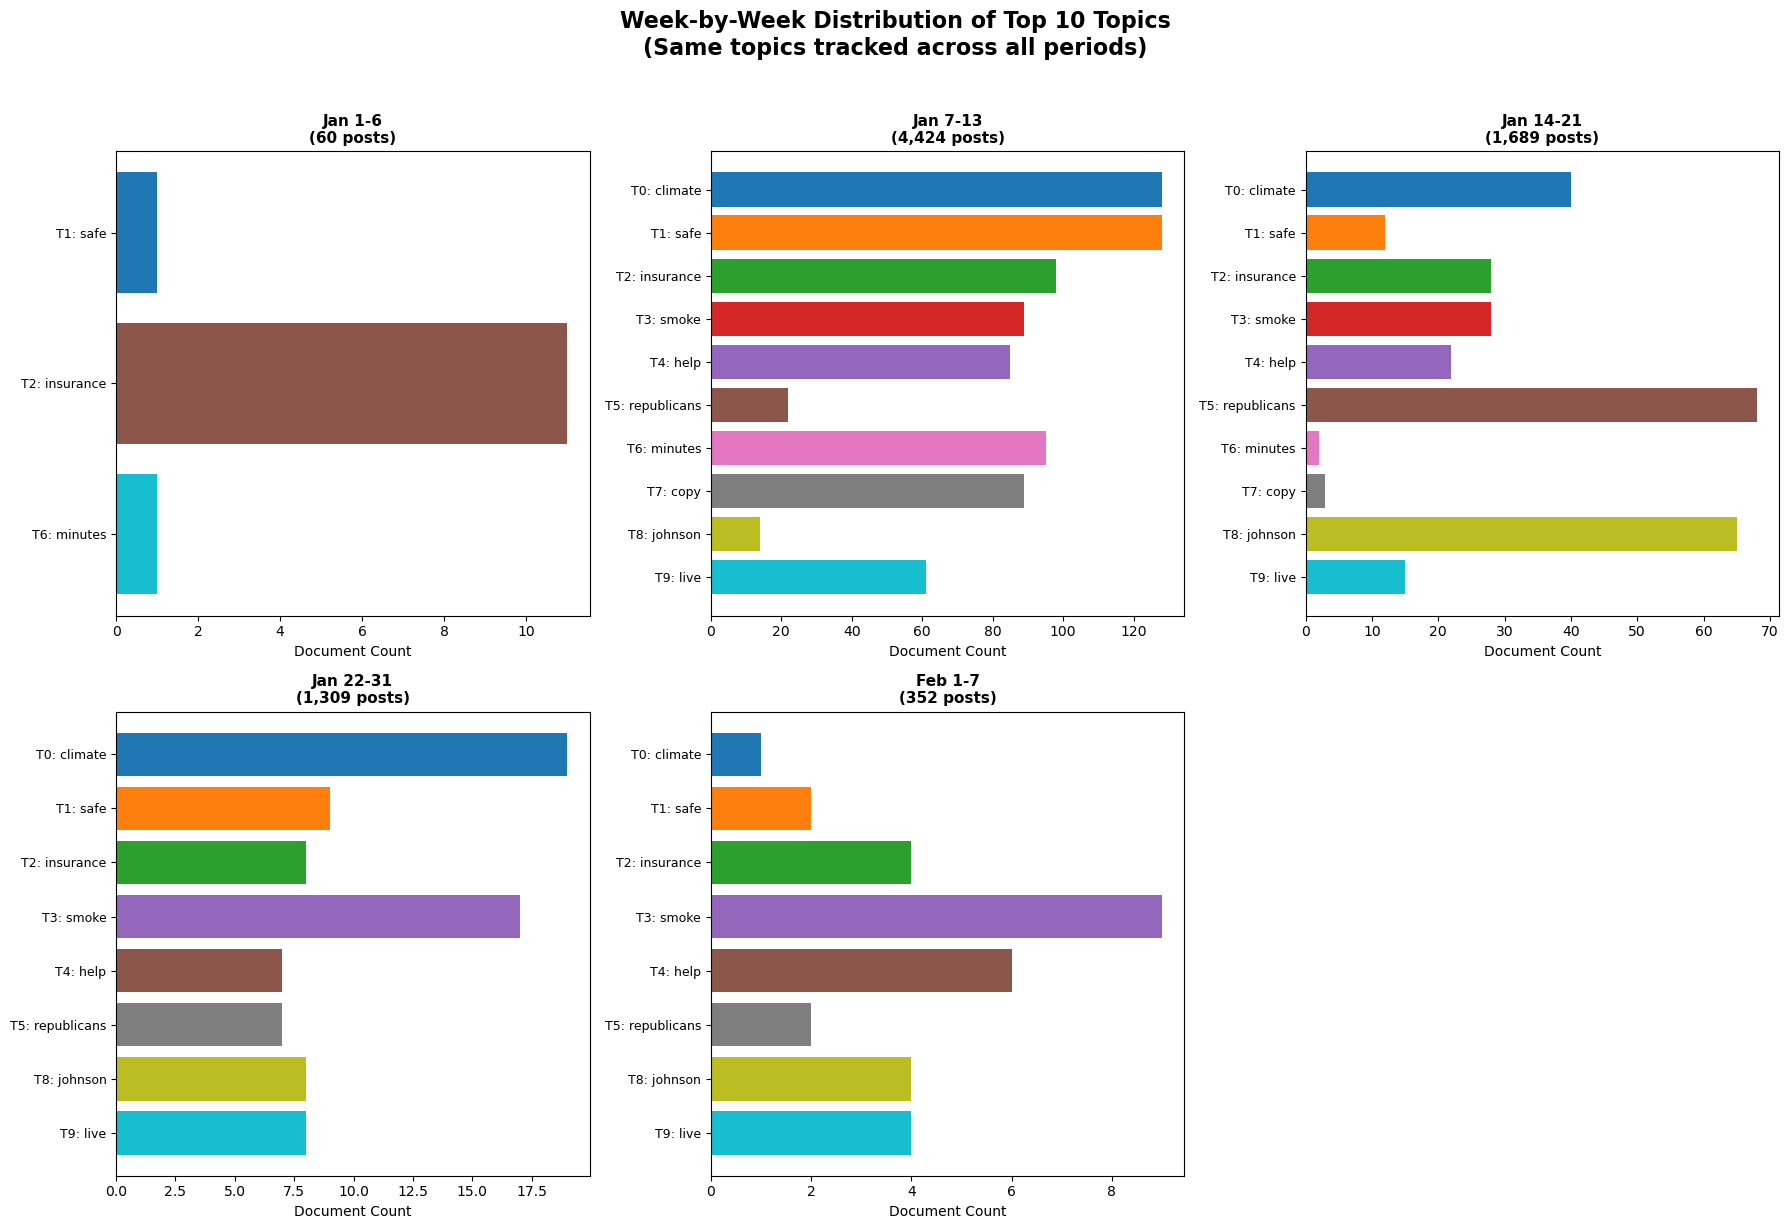


Saved: ../figures/topic_analysis/weekly_topics_collage.png


In [39]:
# Create collage showing top 10 topics distribution per period (using overall model)
if topic_model_all is not None:
    # First, assign topics from overall model to all posts
    posts_with_overall_topics = posts[mask_all].copy()
    posts_with_overall_topics['topic'] = topics_all
    
    # Filter out topic -1 (outliers) and NaT dates
    posts_with_overall_topics = posts_with_overall_topics[posts_with_overall_topics['topic'] != -1]
    posts_with_overall_topics = posts_with_overall_topics.dropna(subset=['date_only'])
    
    # Get top 10 topics from overall model
    topic_info = topic_model_all.get_topic_info()
    valid_topics = topic_info[topic_info['Topic'] != -1].head(10)
    top_10_topic_ids = valid_topics['Topic'].tolist()
    
    # Create topic labels
    topic_labels_short = {}
    for t in top_10_topic_ids:
        words = topic_model_all.get_topic(t)
        if words:
            topic_labels_short[t] = f"T{t}: {words[0][0]}"
        else:
            topic_labels_short[t] = f"Topic {t}"
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, (label, (start, end)) in enumerate(periods.items()):
        ax = axes[idx]
        
        # Filter posts for this period
        mask_period = (posts_with_overall_topics['date_only'] >= start) & \
                      (posts_with_overall_topics['date_only'] <= end)
        period_posts = posts_with_overall_topics[mask_period]
        
        if len(period_posts) > 0:
            # Count topics in this period (only top 10)
            topic_counts = period_posts[period_posts['topic'].isin(top_10_topic_ids)]['topic'].value_counts()
            
            # Ensure all top 10 topics are represented
            counts = [topic_counts.get(t, 0) for t in top_10_topic_ids]
            labels = [topic_labels_short[t] for t in top_10_topic_ids]
            
            # Only show topics with counts > 0
            non_zero = [(l, c) for l, c in zip(labels, counts) if c > 0]
            if non_zero:
                labels, counts = zip(*non_zero)
                colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))
                
                bars = ax.barh(range(len(labels)), counts, color=colors)
                ax.set_yticks(range(len(labels)))
                ax.set_yticklabels(labels, fontsize=9)
                ax.invert_yaxis()
                ax.set_xlabel("Document Count", fontsize=10)
            else:
                ax.text(0.5, 0.5, "No matching topics", ha="center", va="center", fontsize=12)
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
        else:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=12)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        
        ax.set_title(f"{label}\n({period_counts[label]:,} posts)", fontsize=11, fontweight="bold")
    
    # Hide 6th subplot
    axes[5].axis("off")
    
    plt.suptitle("Week-by-Week Distribution of Top 10 Topics\n(Same topics tracked across all periods)", 
                 fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "weekly_topics_collage.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"\nSaved: {OUTPUT_DIR / 'weekly_topics_collage.png'}")

## 3. Topic Evolution Over Time

In [40]:
# Analyze topic evolution using the overall model (fixed topics across all periods)
if topic_model_all is not None:
    # Create timestamps for topics over time
    posts_with_topics = posts[mask_all].copy()
    posts_with_topics['topic'] = topics_all
    
    # Filter out topic -1 (outliers/miscellaneous)
    posts_with_topics = posts_with_topics[posts_with_topics['topic'] != -1]
    
    # Drop rows with NaT dates
    posts_with_topics = posts_with_topics.dropna(subset=['date_only'])
    
    # Assign period labels (handle NaT safely)
    def get_period(date):
        if pd.isna(date):
            return "Other"
        for label, (start, end) in periods.items():
            if start <= date <= end:
                return label
        return "Other"
    
    posts_with_topics['period'] = posts_with_topics['date_only'].apply(get_period)
    posts_with_topics = posts_with_topics[posts_with_topics['period'] != "Other"]
    
    # Count topics per period
    topic_period_counts = posts_with_topics.groupby(['period', 'topic']).size().unstack(fill_value=0)
    
    # Reorder periods
    period_order = list(periods.keys())
    topic_period_counts = topic_period_counts.reindex(period_order)
    
    # Get top 10 topics by total count (these will be consistent across all periods)
    topic_totals = topic_period_counts.sum()
    top_10_topics = topic_totals.nlargest(10).index.tolist()
    
    # Get topic labels for top 10
    topic_labels = {}
    for t in top_10_topics:
        words = topic_model_all.get_topic(t)
        if words:
            top_words = [w[0] for w in words[:3]]
            topic_labels[t] = f"T{t}: {', '.join(top_words)}"
        else:
            topic_labels[t] = f"Topic {t}"
    
    print(f"Top 10 topics (excluding outliers) - consistent across all periods:")
    for t in top_10_topics:
        print(f"  {topic_labels[t]} ({topic_totals[t]} total docs)")
    
    print("\nTopic counts per period (top 10 topics):")
    print(topic_period_counts[top_10_topics])

Top 10 topics (excluding outliers) - consistent across all periods:
  T0: climate, change, noaa (188 total docs)
  T1: safe, stay, friends (152 total docs)
  T2: insurance, companies, policies (149 total docs)
  T3: smoke, air, quality (143 total docs)
  T4: help, canada, mexico (120 total docs)
  T5: republicans, conditions, aid (99 total docs)
  T6: minutes, past, bryant (98 total docs)
  T7: copy, long, ukraine (92 total docs)
  T8: johnson, mike, speaker (91 total docs)
  T9: live, sqmi, n18g (88 total docs)

Topic counts per period (top 10 topics):
topic        0    1   2   3   4   5   6   7   8   9
period                                             
Jan 1-6      0    1  11   0   0   0   1   0   0   0
Jan 7-13   128  128  98  89  85  22  95  89  14  61
Jan 14-21   40   12  28  28  22  68   2   3  65  15
Jan 22-31   19    9   8  17   7   7   0   0   8   8
Feb 1-7      1    2   4   9   6   2   0   0   4   4


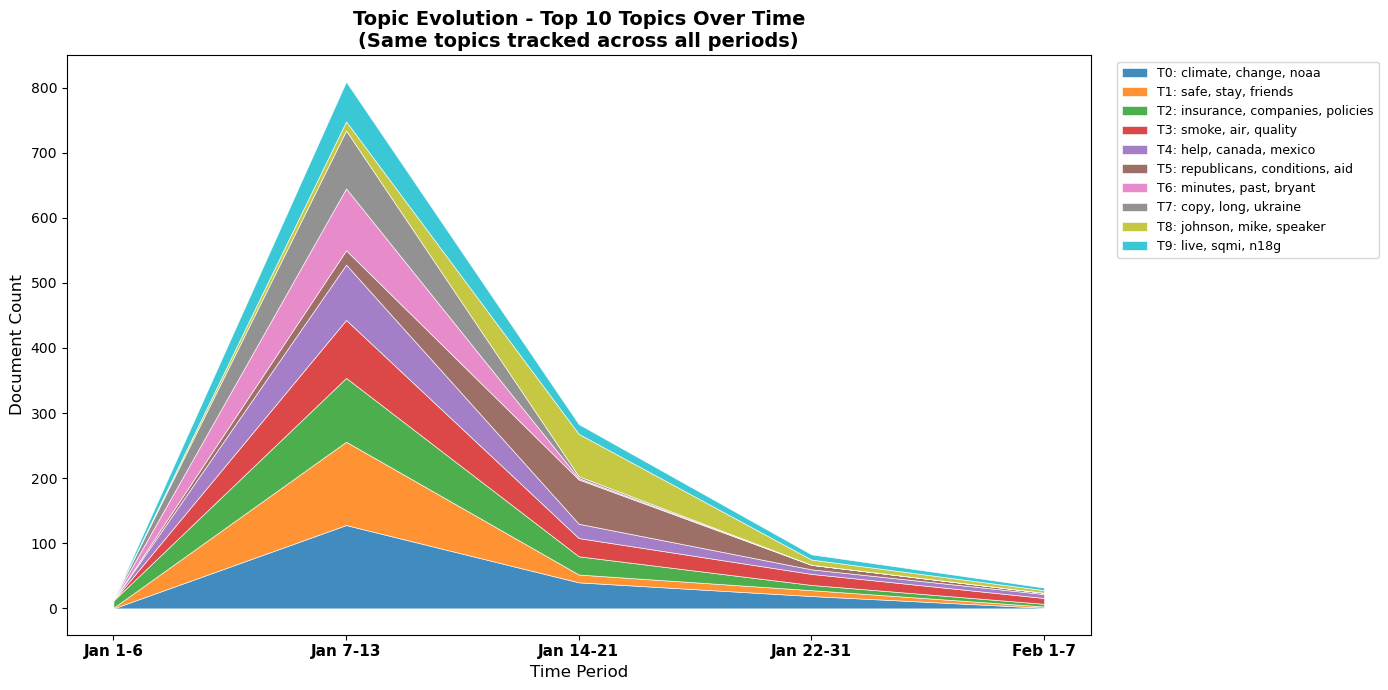


Saved: ../figures/topic_analysis/topic_evolution_stream.png


In [41]:
# Create stream chart for top 10 topics over time (consistent topics)
if topic_model_all is not None and 'top_10_topics' in dir():
    # Plot stream chart using the same top 10 topics
    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(period_order))
    colors = plt.cm.tab10(np.linspace(0, 1, len(top_10_topics)))
    
    bottom = np.zeros(len(period_order))
    for idx, topic in enumerate(top_10_topics):
        if topic in topic_period_counts.columns:
            values = topic_period_counts[topic].values.astype(float)
        else:
            values = np.zeros(len(period_order))
        ax.fill_between(x, bottom, bottom + values, 
                       label=topic_labels[topic], 
                       color=colors[idx], alpha=0.85, 
                       edgecolor='white', linewidth=0.5)
        bottom += values
    
    ax.set_xticks(x)
    ax.set_xticklabels(period_order, fontsize=11, fontweight='bold')
    ax.set_ylabel("Document Count", fontsize=12)
    ax.set_xlabel("Time Period", fontsize=12)
    ax.set_title("Topic Evolution - Top 10 Topics Over Time\n(Same topics tracked across all periods)", 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "topic_evolution_stream.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"\nSaved: {OUTPUT_DIR / 'topic_evolution_stream.png'}")

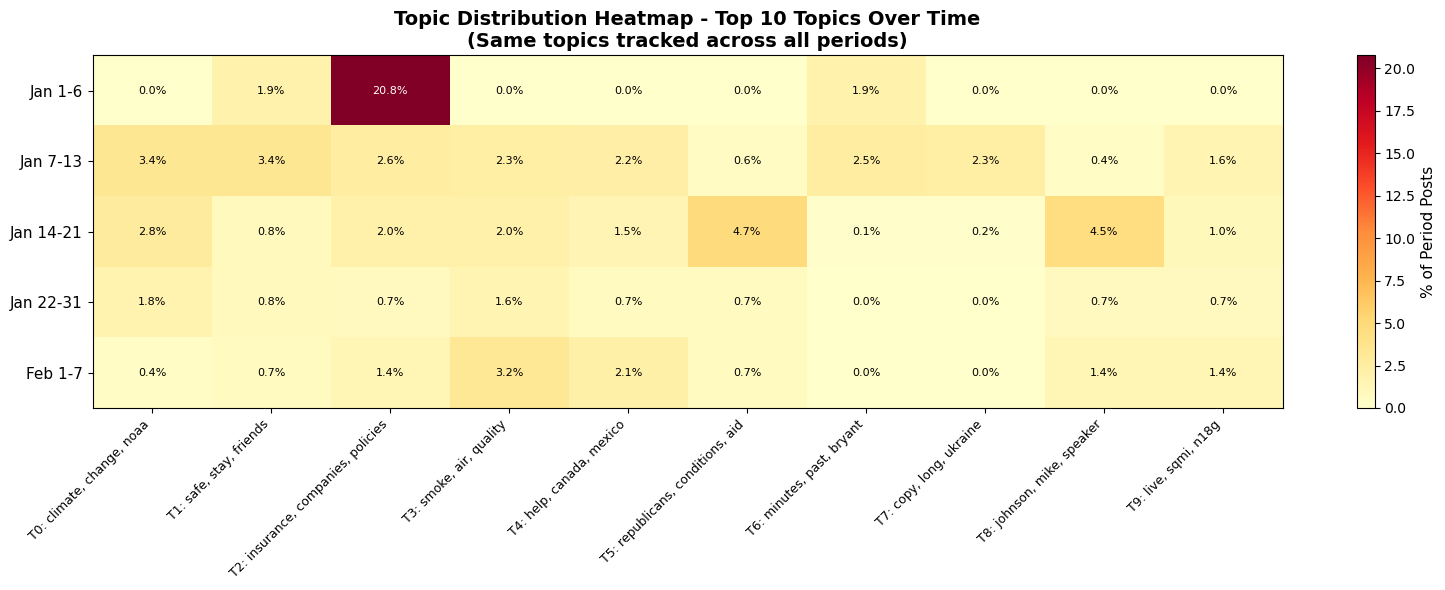


Saved: ../figures/topic_analysis/topic_heatmap.png


In [42]:
# Create heatmap of topic distribution over time (top 10 consistent topics)
if topic_model_all is not None and 'top_10_topics' in dir():
    # Normalize by period (percentage)
    topic_period_pct = topic_period_counts.div(topic_period_counts.sum(axis=1), axis=0) * 100
    
    # Use the same top 10 topics
    heatmap_data = topic_period_pct[top_10_topics]
    
    # Create labels
    col_labels = [topic_labels.get(t, f"T{t}") for t in top_10_topics]
    
    fig, ax = plt.subplots(figsize=(16, 6))
    im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
    
    ax.set_xticks(np.arange(len(top_10_topics)))
    ax.set_yticks(np.arange(len(period_order)))
    ax.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(period_order, fontsize=11)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('% of Period Posts', fontsize=11)
    
    # Add text annotations
    for i in range(len(period_order)):
        for j in range(len(top_10_topics)):
            val = heatmap_data.values[i, j]
            color = 'white' if val > heatmap_data.values.max() / 2 else 'black'
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center', color=color, fontsize=8)
    
    ax.set_title('Topic Distribution Heatmap - Top 10 Topics Over Time\n(Same topics tracked across all periods)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "topic_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"\nSaved: {OUTPUT_DIR / 'topic_heatmap.png'}")